{'domain': {'x_bounds': [5000, 5000], 'y_bounds': [5000, 5000], 'n_cells': [50, 50]}, 'survey': {'x_spacing': 100, 'x_bounds': [-400, 400], 'y_spacing': 100, 'y_bounds': [-400, 400], 'z_height': 1000, 'components': ['tmi']}, 'inducing_field': {'inclination': 90, 'declination': 0, 'amplitude': 50000}, 'mesh': {'dx': 100, 'dy': 100, 'dz': 200, 'x_length': 4000, 'y_length': 4000, 'z_length': 10000}, 'model': {'background_susceptibility': 0.01, 'curie_depth': 5000, 'curie_susceptibility': 0.0001}}


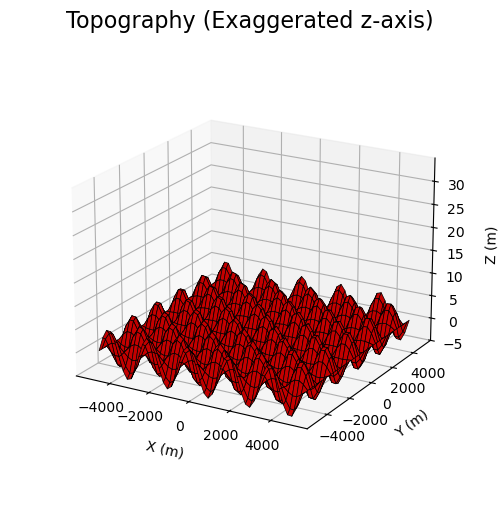

In [1]:
from forward_simulation import ForwardSimulation
from inversion import MagneticsInversion
from matplotlib import pyplot as plt
import numpy as np
import matplotlib as mpl
from discretize.utils import mkvc
from simpeg.utils import plot2Ddata
from simpeg import maps
from simpeg.potential_fields import magnetics

def z_func(x, y):
    return 5*np.sin(2 * np.pi * x / 2000) * np.cos(2 * np.pi * y / 2000)

simulation = ForwardSimulation(
    "forward_model_params.yml",
    z_func=z_func,
    randomize_model=True,
)


fig = plt.figure(figsize=(6, 6))
ax = fig.add_axes([0.1, 0.1, 0.8, 0.8], projection="3d")
ax.set_zlim([simulation.z_topo.max() -10, simulation.z_topo.max()+30])
ax.plot_surface(simulation.x_topo, simulation.y_topo, simulation.z_topo, color="r", edgecolor="k", linewidth=0.5)
ax.set_box_aspect(aspect=None, zoom=0.85)
ax.set_xlabel("X (m)", labelpad=10)
ax.set_ylabel("Y (m)", labelpad=10)
ax.set_zlabel("Z (m)", labelpad=10)
ax.set_title("Topography (Exaggerated z-axis)", fontsize=16, pad=-20)
ax.view_init(elev=20.0)

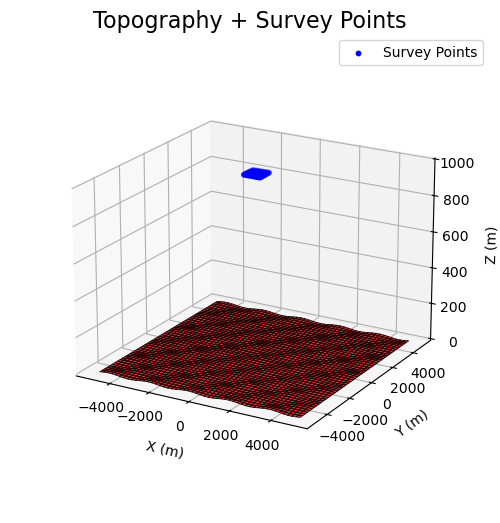

In [2]:
# Visualize survey points on a fresh figure so this cell always renders output
fig2 = plt.figure(figsize=(6, 6))
ax2 = fig2.add_axes([0.1, 0.1, 0.8, 0.8], projection="3d")

# Re-plot topography
ax2.plot_surface(
    simulation.x_topo, simulation.y_topo, simulation.z_topo,
    color="r", edgecolor="k", linewidth=0.5, alpha=0.8
)


X_survey, Y_survey = np.meshgrid(simulation.x_survey, simulation.y_survey)
ax2.scatter(X_survey.ravel(), Y_survey.ravel(), simulation.z_survey.ravel(), color="b", s=10, label="Survey Points")

# Keep z-range including both topography and survey points
zmin = simulation.z_topo.min() - 5
zmax = max(simulation.z_topo.max(), simulation.z_survey.max()) + 5
ax2.set_zlim([zmin, zmax])

ax2.set_box_aspect(aspect=None, zoom=0.85)
ax2.set_xlabel("X (m)", labelpad=10)
ax2.set_ylabel("Y (m)", labelpad=10)
ax2.set_zlabel("Z (m)", labelpad=10)
ax2.set_title("Topography + Survey Points", fontsize=16, pad=-20)
ax2.view_init(elev=20.0)
ax2.legend(loc="upper right")
plt.show()

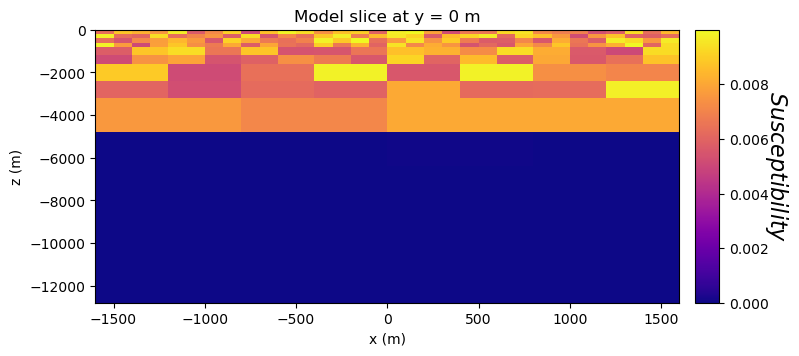

In [3]:
fig = plt.figure(figsize=(8, 3.5))
ax1 = fig.add_axes([0.1, 0.12, 0.73, 0.78])
plotting_map = maps.InjectActiveCells(simulation.mesh, simulation.active_cells, np.nan)

norm = mpl.colors.Normalize(vmin=0, vmax=np.max(simulation.model))
simulation.mesh.plot_slice(
    plotting_map * simulation.model,
    normal="Y",
    ax=ax1,
    ind=int(simulation.mesh.shape_cells[1] / 2),
    grid=False,
    pcolor_opts={"cmap": mpl.cm.plasma, "norm": norm},
)
ax1.set_title("Model slice at y = 0 m")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("z (m)")

ax2 = fig.add_axes([0.85, 0.12, 0.03, 0.78])
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.plasma
)
cbar.set_label("$Susceptibility$", rotation=270, labelpad=15, size=16)

plt.show()

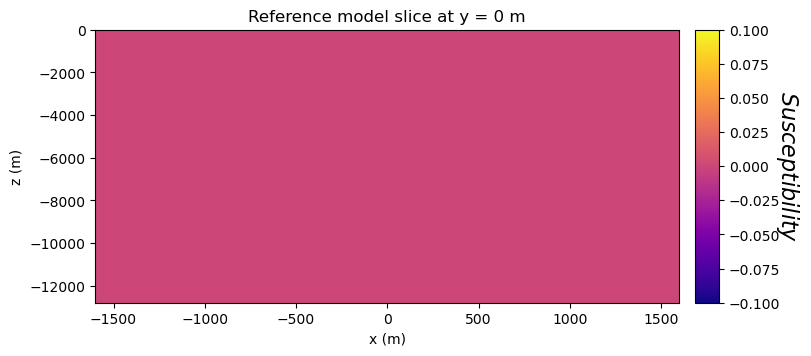

In [4]:
#plot the reference model 
inversion_test = MagneticsInversion(simulation, 0.01, inversion_type="IRLS", invert=False)
inversion_test.build_depth_taper_reference(
    chi0=0.1,      # choose your shallow prior susceptibility
    d_const_m=2000, # 500M
    d_zero_m=10000, # 5KM
)
fig = plt.figure(figsize=(8, 3.5))
ax1 = fig.add_axes([0.1, 0.12, 0.73, 0.78])
plotting_map = maps.InjectActiveCells(simulation.mesh, simulation.active_cells, np.nan)
norm = mpl.colors.Normalize(vmin=0, vmax=np.max(inversion_test.ref_model))
simulation.mesh.plot_slice(plotting_map * inversion_test.ref_model, normal="Y", ax=ax1, ind=int(simulation.mesh.shape_cells[1] / 2), grid=False, pcolor_opts={"cmap": mpl.cm.plasma, "norm": norm})
ax1.set_title("Reference model slice at y = 0 m")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("z (m)")
ax2 = fig.add_axes([0.85, 0.12, 0.03, 0.78])
cbar = mpl.colorbar.ColorbarBase(ax2, norm=norm, orientation="vertical", cmap=mpl.cm.plasma)
cbar.set_label("$Susceptibility$", rotation=270, labelpad=15, size=16)
plt.show()

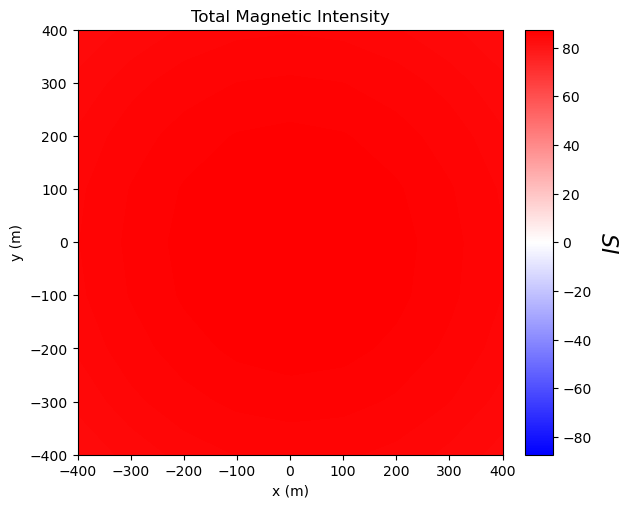

In [5]:
#view the forward simulation results
fig = plt.figure(figsize=(7, 5))
ax1 = fig.add_axes([0.1, 0.1, 0.75, 0.85])
x_grid, y_grid = np.meshgrid(simulation.x_survey, simulation.y_survey)
locations = np.c_[mkvc(x_grid), mkvc(y_grid), mkvc(simulation.z_survey)]

# Use the observation locations and components to define the receivers. To
# simulate data, the receivers must be defined as a list.
receiver_list = magnetics.receivers.Point(locations, components=["tmi"])
receiver_list = [receiver_list]

norm = mpl.colors.Normalize(vmin=-np.max(np.abs(simulation.dpred)), vmax=np.max(np.abs(simulation.dpred)))
plot2Ddata(
    receiver_list[0].locations,
    simulation.dpred,
    ax=ax1,
    ncontour=40,
    contourOpts={"cmap": mpl.cm.bwr, "norm": norm},
)
ax1.set_title("Total Magnetic Intensity")
ax1.set_xlabel("x (m)")
ax1.set_ylabel("y (m)")

ax2 = fig.add_axes([0.81, 0.1, 0.04, 0.85])
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.bwr
)
cbar.set_label("$SI$", rotation=270, labelpad=20, size=16)

plt.show()

In [ ]:
inversion = MagneticsInversion(simulation, 0.01)
dpred_inversion = inversion.inv_problem.dpred
dobs = inversion.forward_simulation.dpred

data_array = np.c_[dobs, dpred_inversion, (dobs - dpred_inversion)]

fig = plt.figure(figsize=(12, 5))
plot_title = ["Observed", "Predicted", "Data Misfit"]
plot_units = ["nT", "nT", "nT"]

ax1 = 3 * [None]
ax2 = 3 * [None]
norm = 3 * [None]
cbar = 3 * [None]
cplot = 3 * [None]
v_lim = [np.max(np.abs(dobs)), np.max(np.abs(dobs)), np.max(np.abs(dobs - dpred_inversion))]

for ii in range(0, 3):
    ax1[ii] = fig.add_axes([0.3 * ii + 0.1, 0.2, 0.27, 0.75])
    norm[ii] = mpl.colors.Normalize(vmin=-v_lim[ii], vmax=v_lim[ii])
    cplot[ii] = plot2Ddata(
        receiver_list[0].locations,
        data_array[:, ii],
        ax=ax1[ii],
        ncontour=30,
        contourOpts={"cmap": "bwr", "norm": norm[ii]},
    )
    ax1[ii].set_title(plot_title[ii])
    ax1[ii].set_xlabel("x (m)")
    if ii == 0:
        ax1[ii].set_ylabel("y (m)")
    else:
        ax1[ii].set_yticks([])

    ax2[ii] = fig.add_axes([0.3 * ii + 0.1, 0.05, 0.27, 0.05])
    cbar[ii] = mpl.colorbar.ColorbarBase(
        ax2[ii], norm=norm[ii], orientation="horizontal", cmap=mpl.cm.bwr
    )
    cbar[ii].set_label(plot_units[ii], labelpad=5)

plt.show()



Running inversion with SimPEG v0.25.0


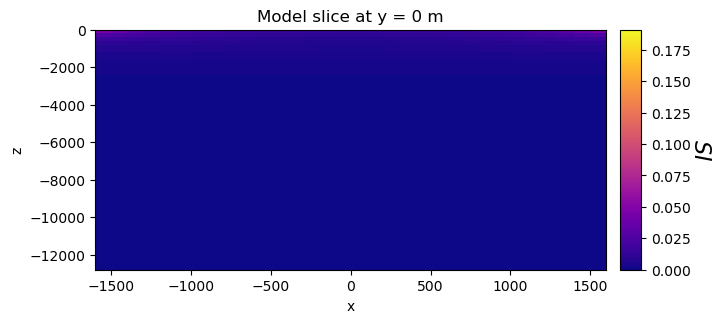

In [ ]:
fig = plt.figure(figsize=(7, 3))
ax1 = fig.add_axes([0.1, 0.1, 0.73, 0.8])

recovered_model = inversion.recovered_model
mesh = simulation.mesh
plotting_map = maps.InjectActiveCells(mesh, simulation.active_cells, np.nan)

norm = mpl.colors.Normalize(
    vmin=np.min(recovered_model), vmax=np.max(recovered_model)
)
mesh.plot_slice(
    plotting_map * recovered_model,
    normal="Y",
    ax=ax1,
    ind=int(mesh.shape_cells[1] / 2),
    grid=False,
    pcolor_opts={"cmap": mpl.cm.plasma, "norm": norm},
)
ax1.set_title("Model slice at y = 0 m")

ax2 = fig.add_axes([0.85, 0.1, 0.03, 0.8])
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.plasma
)
cbar.set_label("$SI$", rotation=270, labelpad=15, size=16)

plt.show()

# Iteratively Re-weighted Least-Squares Inversion

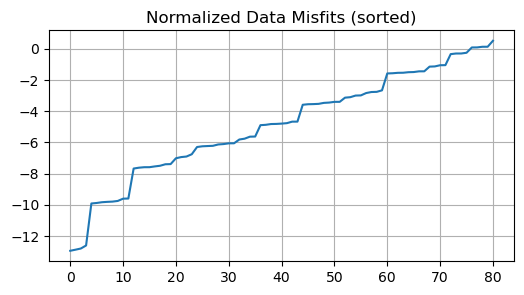

In [ ]:
normalized_data_misfits = (dobs - dpred_inversion) / inversion.uncertainty
fig = plt.figure(figsize=(6, 3))
ax = fig.add_subplot(111)
ax.plot(np.sort(normalized_data_misfits))
ax.set_title("Normalized Data Misfits (sorted)")
ax.grid()
plt.show(fig)


Running inversion with SimPEG v0.25.0
================================================= Projected GNCG =================================================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS   iter_CG   CG |Ax-b|/|b|  CG |Ax-b|   Comment   
-----------------------------------------------------------------------------------------------------------------
   0  4.80e+05  3.78e+06  2.88e+03  1.39e+09                         0           inf          inf                
   1  4.80e+05  2.55e+08  2.67e+02  3.83e+08    8.27e+08      0      6        2.68e-03     2.22e+06              
   2  2.40e+05  1.42e+08  6.00e+02  2.86e+08    6.70e+05      0      5        5.40e-03     7.54e+05              
   3  1.20e+05  6.44e+07  1.05e+03  1.90e+08    4.24e+05      0      4        4.37e-03     4.53e+05              
   4  6.00e+04  2.34e+07  1.52e+03  1.14e+08    2.88e+05      0      4        2.87e-03     1.94e+05              
   5  3.00e+04  7.33e+06  1.88e+03  6.37e+07    

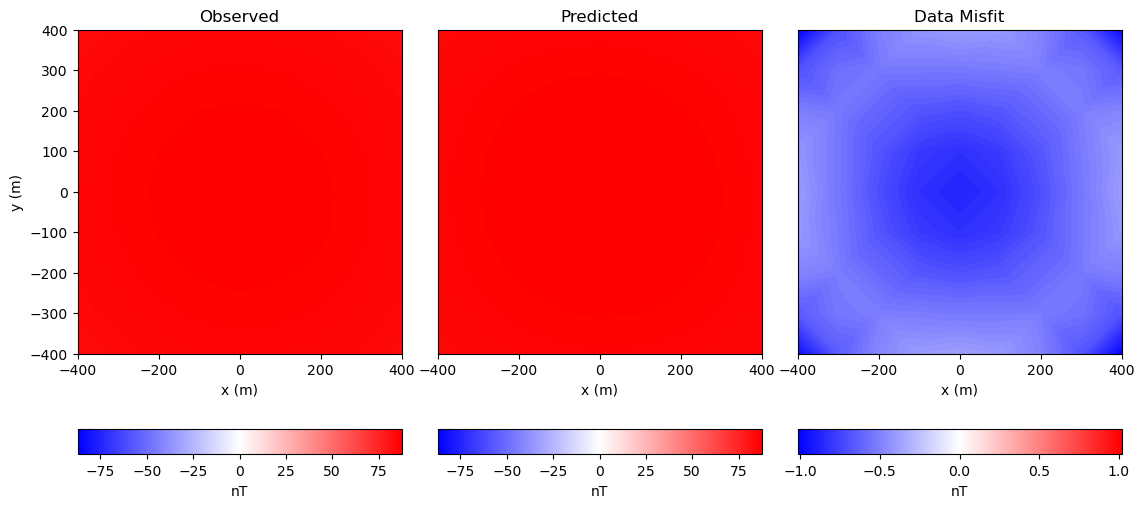

In [ ]:
new_uncertainties = inversion.uncertainty.copy()
new_uncertainties[np.abs(normalized_data_misfits) > 2.0] /= 2.5

irls_inv = MagneticsInversion(simulation, 0.01, inversion_type="IRLS", target_chifact=None, uncertainty=new_uncertainties)
dpred_inversion = irls_inv.inv_problem.dpred
dobs = irls_inv.forward_simulation.dpred

data_array = np.c_[dobs, dpred_inversion, (dobs - dpred_inversion)]

fig = plt.figure(figsize=(12, 5))
plot_title = ["Observed", "Predicted", "Data Misfit"]
plot_units = ["nT", "nT", "nT"]

ax1 = 3 * [None]
ax2 = 3 * [None]
norm = 3 * [None]
cbar = 3 * [None]
cplot = 3 * [None]
v_lim = [np.max(np.abs(dobs)), np.max(np.abs(dobs)), np.max(np.abs(dobs - dpred_inversion))]

for ii in range(0, 3):
    ax1[ii] = fig.add_axes([0.3 * ii + 0.1, 0.2, 0.27, 0.75])
    norm[ii] = mpl.colors.Normalize(vmin=-v_lim[ii], vmax=v_lim[ii])
    cplot[ii] = plot2Ddata(
        receiver_list[0].locations,
        data_array[:, ii],
        ax=ax1[ii],
        ncontour=30,
        contourOpts={"cmap": "bwr", "norm": norm[ii]},
    )
    ax1[ii].set_title(plot_title[ii])
    ax1[ii].set_xlabel("x (m)")
    if ii == 0:
        ax1[ii].set_ylabel("y (m)")
    else:
        ax1[ii].set_yticks([])

    ax2[ii] = fig.add_axes([0.3 * ii + 0.1, 0.05, 0.27, 0.05])
    cbar[ii] = mpl.colorbar.ColorbarBase(
        ax2[ii], norm=norm[ii], orientation="horizontal", cmap=mpl.cm.bwr
    )
    cbar[ii].set_label(plot_units[ii], labelpad=5)

plt.show()



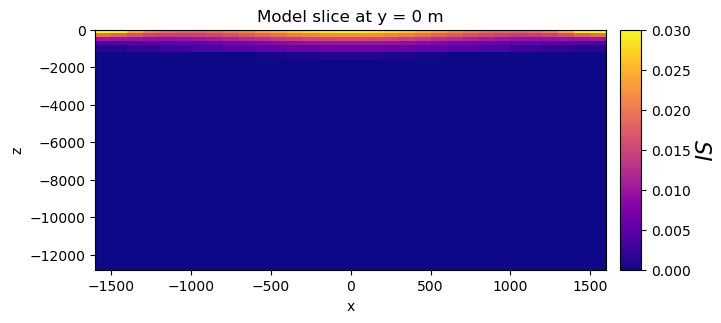

In [ ]:
fig = plt.figure(figsize=(7, 3))
ax1 = fig.add_axes([0.1, 0.1, 0.73, 0.8])

recovered_model = irls_inv.recovered_model
mesh = simulation.mesh
plotting_map = maps.InjectActiveCells(mesh, simulation.active_cells, np.nan)

norm = mpl.colors.Normalize(
    vmin=np.min(recovered_model), vmax=0.03
)
mesh.plot_slice(
    plotting_map * recovered_model,
    normal="Y",
    ax=ax1,
    ind=int(mesh.shape_cells[1] / 2),
    grid=False,
    pcolor_opts={"cmap": mpl.cm.plasma, "norm": norm},
)
ax1.set_title("Model slice at y = 0 m")

ax2 = fig.add_axes([0.85, 0.1, 0.03, 0.8])
cbar = mpl.colorbar.ColorbarBase(
    ax2, norm=norm, orientation="vertical", cmap=mpl.cm.plasma
)
cbar.set_label("$SI$", rotation=270, labelpad=15, size=16)

plt.show()